# Tutorial Classification

> Tutorial Classification

In [ ]:
#| default_exp tutorial_1

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist

from monai.utils import set_determinism
# from monai.transforms import ScaleIntensity

set_determinism(0)

In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
image_path = '../_data/medmnist_data/'
info = download_medmnist('bloodmnist', image_path, download_only=True)
info

100%|██████████| 35461855/35461855 [00:11<00:00, 2977570.70it/s]


Using downloaded and verified file: ../_data/medmnist_data/bloodmnist.npz
Using downloaded and verified file: ../_data/medmnist_data/bloodmnist.npz
Saving training images to ../_data/medmnist_data/...


100%|██████████| 11959/11959 [00:02<00:00, 5486.71it/s]


Saving validation images to ../_data/medmnist_data/...


100%|██████████| 1712/1712 [00:00<00:00, 5376.07it/s]


Saving test images to ../_data/medmnist_data/...


100%|██████████| 3421/3421 [00:00<00:00, 5501.73it/s]

Removed bloodmnist.npz
Datasets downloaded to ../_data/medmnist_data/
Dataset info for 'bloodmnist': {'python_class': 'BloodMNIST', 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1', 'MD5': '7053d0359d879ad8a5505303e11de1dc', 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1', 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b', 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1', 'MD5_128': 'adace1

{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

### Create Dataloader

In [ ]:
from fastai.vision.all import *

In [ ]:
bs, size = 4, 128

path = Path(image_path)
path_train = path/'train'
path_val = path/'val'

data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageMulti), CategoryBlock(vocab=info['label'])),
    'get_items':    get_image_files,
    'get_y':        parent_label,
    'splitter':     GrandparentSplitter(),
    'item_tfms':    [Resample(2)],
    'bs': bs,
}

data = get_dataloader(
    path, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 17092 items
2 datasets of sizes 13674,3418
Setting up Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
Setting up Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False}

Building one sample
  Pipeline: BioImageMulti.create -> Tensor2BioImage -- {}
    starting from
      ../_data/medmnist_data/train/5/train_2282.png
    applying BioImageMulti.create gives
      BioImageMulti of size 3x28x28
    applying Tensor2BioImage -- {} gives
      BioImageMulti of size 3x28x28
  Pipeline: parent_label -> Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False}
    starting from
      ../_data/medmnist_data/train/5/train_2282.png
    applying parent_label gives
      5
    applying Categorize -- {'vocab': ['0', '1', '2', '3', '4', '5', '6', '7'], 'sort': True, 'add_na': False} gives
      TensorCategory(5)

Final sample: (BioImageMulti([[[209

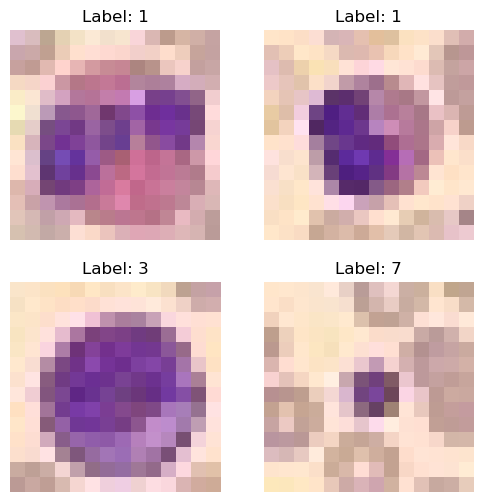

In [ ]:
data.show_batch(max_n=4)

### Load and train a 2D model

In [ ]:
from monai.networks.nets import densenet121

In [ ]:
# model = densenet121(spatial_dims=2, in_channels=1, out_channels=8)
 
loss = CrossEntropyLossFlat()
# metrics = [SSIMMetric, MSELoss]

# trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

trainer = vision_learner(data, resnet18, loss_func=loss, metrics=partial(accuracy_multi, thresh=0.5))

In [ ]:
trainer.fit(1)

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!